In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
BASE = Path("C:/Users/nanig/OneDrive/Desktop/bluestock_mf_capstone")
PROCESSED = BASE / "data/processed"
CHARTS = BASE / "data/processed/charts"

# Load data
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

transactions = pd.read_csv(PROCESSED / "clean_transactions.csv")
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

performance = pd.read_csv(PROCESSED / "clean_performance.csv")
fund_master = pd.read_csv(PROCESSED / "clean_fund_master.csv")
portfolio = pd.read_csv(PROCESSED / "clean_portfolio.csv")

# Compute daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("✅ Data loaded!")
print(f"NAV: {nav.shape}")
print(f"Transactions: {transactions.shape}")


✅ Data loaded!
NAV: (46000, 4)
Transactions: (32778, 13)


In [4]:
# === COMPUTE VAR & CVAR ===
var_data = []

for code in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    
    if len(returns) > 0:
        # Historical VaR (95%)
        var_95 = np.percentile(returns, 5)
        
        # CVaR (mean of returns below VaR)
        cvar_95 = returns[returns <= var_95].mean()
        
        var_data.append({
            'amfi_code': code,
            'var_95': var_95,
            'cvar_95': cvar_95
        })

var_df = pd.DataFrame(var_data)

# Save
var_df.to_csv(PROCESSED / 'var_cvar_report.csv', index=False)

print("✅ VaR & CVaR Calculated!")
print(var_df.nsmallest(10, 'var_95'))

✅ VaR & CVaR Calculated!
    amfi_code    var_95   cvar_95
22     119599 -0.026859 -0.032384
17     119095 -0.026188 -0.031667
4      101207 -0.026021 -0.032459
11     118634 -0.025438 -0.032304
21     119598 -0.024507 -0.030595
39     149324 -0.023483 -0.031036
7      102886 -0.019220 -0.023251
2      100033 -0.019034 -0.023456
25     120505 -0.018892 -0.024342
16     119094 -0.018480 -0.024260


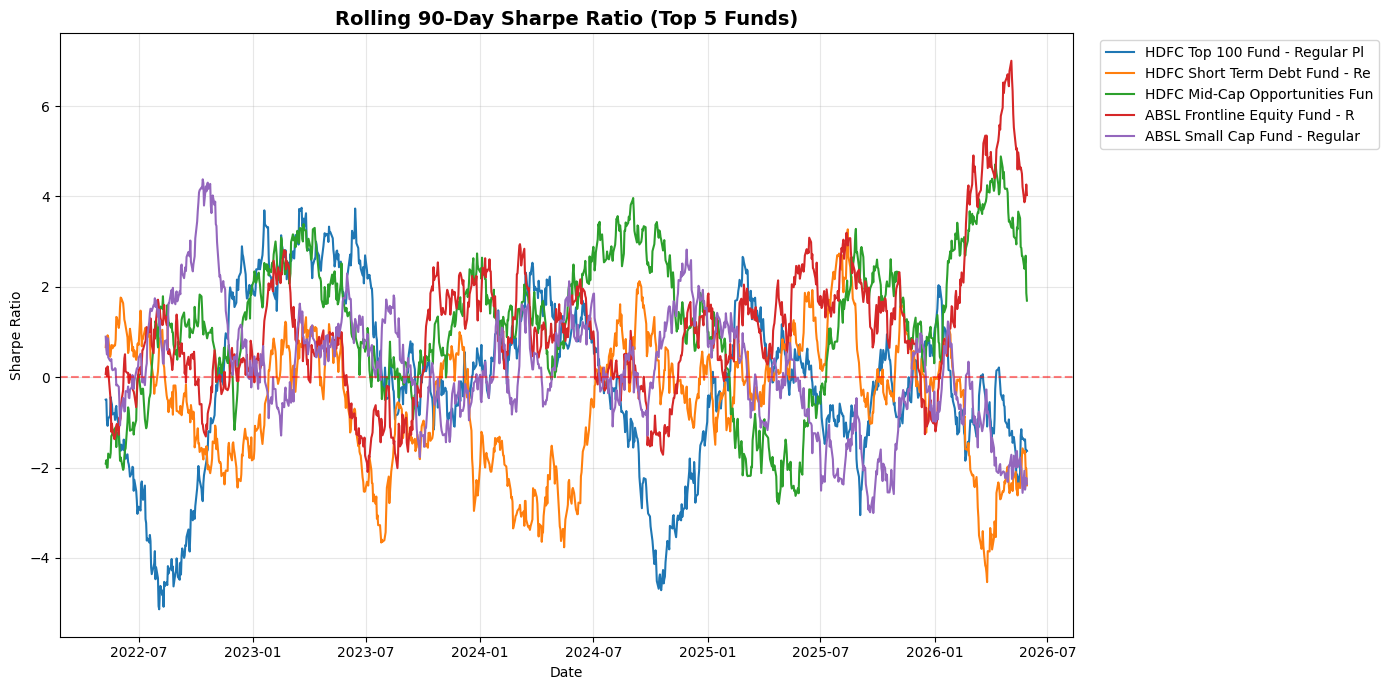

✅ Rolling Sharpe Chart saved!


In [5]:
# === ROLLING SHARPE RATIO ===
RISK_FREE_RATE = 0.065 / 252

# Get top 5 funds by amfi_code
top5_codes = nav.groupby('amfi_code')['nav'].count().sort_values(ascending=False).head(5).index

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_returns = nav[nav['amfi_code'] == code].set_index('date')['daily_return']
    
    rolling_sharpe = (
        fund_returns.rolling(90).mean() - RISK_FREE_RATE
    ) / fund_returns.rolling(90).std() * np.sqrt(252)
    
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0][:30]
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1.5)

plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS / 'rolling_sharpe_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Rolling Sharpe Chart saved!")

In [6]:
# === INVESTOR COHORT ANALYSIS ===

# Get first transaction year per investor
cohort = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
cohort['cohort_year'] = cohort['transaction_date'].dt.year

# Merge back
transactions_cohort = transactions.merge(cohort[['investor_id', 'cohort_year']], on='investor_id')

# SIP transactions only
sip_cohort = transactions_cohort[transactions_cohort['transaction_type'].str.lower() == 'sip']

# Cohort analysis
cohort_analysis = sip_cohort.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investor_count=('investor_id', 'nunique'),
    transaction_count=('investor_id', 'count')
).reset_index()

cohort_analysis.to_csv(PROCESSED / 'cohort_analysis.csv', index=False)
print("✅ Cohort Analysis Done!")
print(cohort_analysis)

✅ Cohort Analysis Done!
   cohort_year  avg_sip_amount  total_invested  investor_count  \
0         2024    10996.885825       214978121            4624   
1         2025    13505.209581         2255370             138   

   transaction_count  
0              19549  
1                167  


In [7]:
# === SIP CONTINUATION ANALYSIS ===

# Filter SIP transactions
sip_tx = transactions[transactions['transaction_type'].str.lower() == 'sip'].copy()
sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_counts = sip_tx.groupby('investor_id').size()
active_investors = sip_counts[sip_counts >= 6].index

sip_active = sip_tx[sip_tx['investor_id'].isin(active_investors)].copy()

# Compute gap between transactions
sip_active['prev_date'] = sip_active.groupby('investor_id')['transaction_date'].shift(1)
sip_active['gap_days'] = (sip_active['transaction_date'] - sip_active['prev_date']).dt.days

# Average gap per investor
investor_gaps = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
investor_gaps.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors
investor_gaps['at_risk'] = investor_gaps['avg_gap_days'] > 35

# Save
investor_gaps.to_csv(PROCESSED / 'sip_continuity.csv', index=False)

print("✅ SIP Continuity Analysis Done!")
print(f"Total investors: {len(investor_gaps)}")
print(f"At-risk investors: {investor_gaps['at_risk'].sum()}")
print(f"Safe investors: {(~investor_gaps['at_risk']).sum()}")

✅ SIP Continuity Analysis Done!
Total investors: 1362
At-risk investors: 1332
Safe investors: 30


In [9]:
# === FUND RECOMMENDER ===
def recommend_funds(risk_appetite):
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    grades = risk_map.get(risk_appetite, ['Moderate'])
    filtered = performance[performance['risk_grade'].isin(grades)]
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'risk_grade', 'sharpe_ratio', 'return_1yr_pct']
    ]
    return top3

# Test
for risk in ['Low', 'Moderate', 'High']:
    print(f"\n🎯 Top 3 Funds for {risk} Risk:")
    print(recommend_funds(risk).to_string(index=False))
    print("-" * 60)


🎯 Top 3 Funds for Low Risk:
                             scheme_name risk_grade  sharpe_ratio  return_1yr_pct
ICICI Pru Liquid Fund - Regular - Growth        Low          7.68            8.89
    Kotak Liquid Fund - Regular - Growth        Low          6.18            4.26
     ABSL Liquid Fund - Regular - Growth        Low          5.14            6.18
------------------------------------------------------------

🎯 Top 3 Funds for Moderate Risk:
                                  scheme_name risk_grade  sharpe_ratio  return_1yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06           10.94
Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06           15.12
    ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03           14.12
------------------------------------------------------------

🎯 Top 3 Funds for High Risk:
                                  scheme_name risk_grade  sharpe_ratio  return_1yr_pct
Kotak Emerging Equity 

In [10]:
# Save recommender.py
BASE = Path("C:/Users/nanig/OneDrive/Desktop/bluestock_mf_capstone")

recommender_code = """import pandas as pd
from pathlib import Path

PROCESSED = Path("C:/Users/nanig/OneDrive/Desktop/bluestock_mf_capstone/data/processed")
performance = pd.read_csv(PROCESSED / "clean_performance.csv")

def recommend_funds(risk_appetite):
    risk_map = {
        "Low": ["Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }
    grades = risk_map.get(risk_appetite, ["Moderate"])
    filtered = performance[performance["risk_grade"].isin(grades)]
    top3 = filtered.nlargest(3, "sharpe_ratio")[
        ["scheme_name", "risk_grade", "sharpe_ratio", "return_1yr_pct"]
    ]
    return top3

if __name__ == "__main__":
    for risk in ["Low", "Moderate", "High"]:
        print(f"Top 3 Funds for {risk} Risk:")
        print(recommend_funds(risk))
        print()
"""

with open(BASE / "scripts/recommender.py", "w") as f:
    f.write(recommender_code)

print("✅ recommender.py saved!")

✅ recommender.py saved!


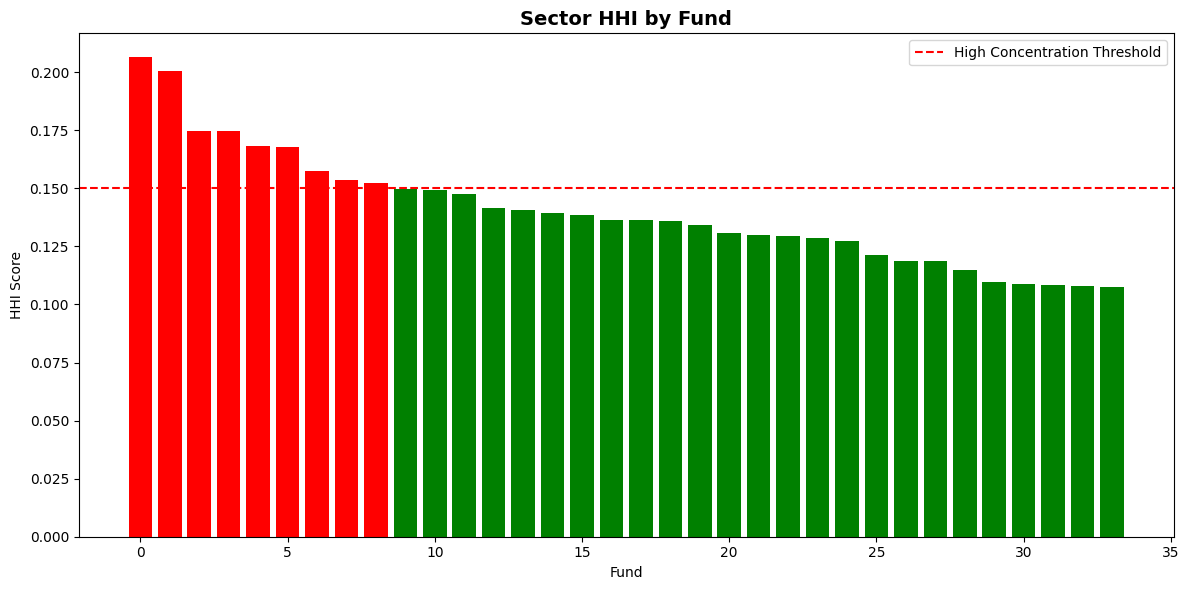

✅ Sector HHI Analysis Done!
                                       scheme_name       hhi concentration
19           Axis Bluechip Fund - Regular - Growth  0.206448          High
24          ABSL Small Cap Fund - Regular - Growth  0.200700          High
3        SBI Small Cap Fund - Direct Plan - Growth  0.174751          High
25      UTI Nifty 50 Index Fund - Regular - Growth  0.174709          High
12  Nippon India Large Cap Fund - Regular - Growth  0.168298          High


In [11]:
# === SECTOR HHI ANALYSIS ===

# Compute HHI for each fund
hhi_data = []

for code in portfolio['amfi_code'].unique():
    fund_port = portfolio[portfolio['amfi_code'] == code]
    
    # HHI = sum of squared weights
    weights = fund_port['weight_pct'].values / 100
    hhi = np.sum(weights ** 2)
    
    hhi_data.append({
        'amfi_code': code,
        'hhi': hhi,
        'concentration': 'High' if hhi > 0.15 else 'Low'
    })

hhi_df = pd.DataFrame(hhi_data)
hhi_df = hhi_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Save
hhi_df.to_csv(PROCESSED / 'sector_hhi.csv', index=False)

# Chart
plt.figure(figsize=(12, 6))
hhi_sorted = hhi_df.sort_values('hhi', ascending=False)
colors = ['red' if x == 'High' else 'green' for x in hhi_sorted['concentration']]
plt.bar(range(len(hhi_sorted)), hhi_sorted['hhi'], color=colors)
plt.title('Sector HHI by Fund', fontsize=14, fontweight='bold')
plt.xlabel('Fund')
plt.ylabel('HHI Score')
plt.axhline(y=0.15, color='red', linestyle='--', label='High Concentration Threshold')
plt.legend()
plt.tight_layout()
plt.savefig(CHARTS / 'sector_hhi.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sector HHI Analysis Done!")
print(hhi_df.nlargest(5, 'hhi')[['scheme_name', 'hhi', 'concentration']])